# Fitting Simple Linear Statistical Models
## Adding qualitative factors

Every predictor we have used so far has been a **number**: days of stay, count of services. But much of what we know about a medical event is not a number at all:

- Was it an **emergency visit** or an **inpatient admission**?
- What **kind of condition** was being treated?
- Which **hospital** provided the care?

These are **qualitative** (or **categorical**) variables. They describe which *group* an event belongs to, not how much of something it has.

This notebook answers three questions:

1. How do you put a category into a regression at all?
2. How do you read the result?
3. What happens when a group difference is really caused by something else?

That third question turns out to be the important one.

---
## 1. Setup

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["figure.dpi"] = 110


# ---- a small helper we will use after every model ----
import re

def tidy(name):
    """Turn statsmodels' internal term names into readable ones."""
    name = name.replace("np.log1p(LOS)", "log(LOS + 1)").replace("np.log(", "log(")
    match = re.search(r"C\((\w+).*?\)\[T\.(.+?)\]$", name)
    if match:
        return f"[{match.group(1)} = {match.group(2)}]"
    return name

def show_equation(model, response, digits=2):
    """Print the fitted model as an equation."""
    p = model.params
    lines = [f"{response} = {p['Intercept']:,.{digits}f}"]
    pad = " " * (len(response) + 3)
    for name, coef in p.items():
        if name == "Intercept":
            continue
        sign = "+" if coef >= 0 else "-"
        lines.append(f"{pad}{sign} {abs(coef):,.{digits}f} x {tidy(name)}")
    print("\n".join(lines))

---
## 2. The data

In [89]:
URL = ("https://raw.githubusercontent.com/thousandoaks/Python4DS-I/"
       "main/datasets/HealthcareDataset_PublicRelease.csv")

try:
    events = pd.read_csv("medical_events.csv", parse_dates=["StartDate", "EndDate", "BirthDate"])
    print("loaded medical_events.csv")
except FileNotFoundError:
    print("rebuilding from source")
    lines = pd.read_csv(URL, parse_dates=["StartDate", "EndDate", "BirthDate"])
    lines["LOS"] = (lines.EndDate - lines.StartDate).dt.days
    events = (lines.groupby("MedicalClaim")
              .agg(TotalCost=("TotalExpenses", "sum"),
                   NumRevCodes=("RevenueCode", "nunique"),
                   LOS=("LOS", "first"),
                   TypeFlag=("TypeFlag", "first"),
                   HospitalType=("HospitalType", "first"),
                   Diagnosis=("PrincipalDiagnosis", "first"))
              .reset_index())

# the model we finished with last week
model_log = smf.ols("np.log(TotalCost) ~ np.log1p(LOS) + np.log(NumRevCodes)",
                    data=events).fit()

print(f"{len(events):,} medical events")
print(f"R-squared from last week's log model: {model_log.rsquared:.3f}")
print()
show_equation(model_log, "log(TotalCost)", digits=3)

rebuilding from source
3,361 medical events
R-squared from last week's log model: 0.803

log(TotalCost) = 6.942
                 + 0.490 x log(LOS + 1)
                 + 1.091 x log(NumRevCodes)


### 2.1 How to read a fitted equation

Every model in this notebook will be printed in this form. It is worth being able to read one.

- The first number is the **intercept**: the predicted value when every other term is zero.
- Each remaining line is a **coefficient multiplied by a variable**. The coefficient is how much the prediction changes when that variable goes up by one.
- Because this model predicts $\log(\text{TotalCost})$, the numbers are on the log scale. A coefficient of 1.091 on $\log(\text{NumRevCodes})$ means a 1% rise in services is associated with roughly a 1.091% rise in cost.

To predict an event, substitute its values and add everything up.

---
## 3. Our first category: emergency or inpatient?

`TypeFlag` records whether an event was an emergency visit (`ER`) or an inpatient admission (`INP`). Start where you always should — by looking at the groups themselves.

In [90]:
by_type = events.groupby("TypeFlag").agg(
    events=("TotalCost", "size"),
    average_cost=("TotalCost", "mean"),
    average_LOS=("LOS", "mean"),
    average_services=("NumRevCodes", "mean"),
)
display(by_type.round(1))

ratio = by_type.loc["INP", "average_cost"] / by_type.loc["ER", "average_cost"]
print(f"\ninpatient events cost {ratio:.1f} times as much as emergency events, on average")

,events,average_cost,average_LOS,average_services
TypeFlag,,,,
ER,1871,"11,840.60",0.30,7.00
INP,1490,"81,623.00",5.50,19.10



inpatient events cost 6.9 times as much as emergency events, on average


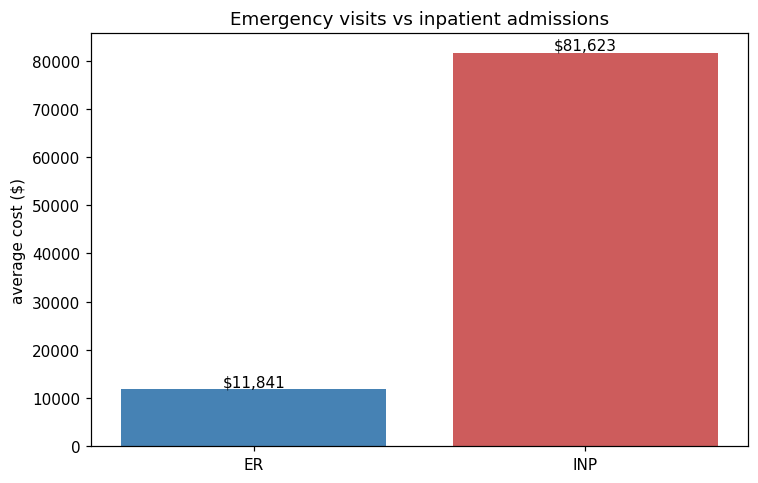

In [91]:
plt.bar(by_type.index, by_type.average_cost, color=["steelblue", "indianred"])
plt.ylabel("average cost ($)")
plt.title("Emergency visits vs inpatient admissions")
for i, v in enumerate(by_type.average_cost):
    plt.text(i, v, f"${v:,.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

An enormous gap: inpatient admissions average about \$81,600 against \$11,800 for emergency visits — **roughly seven times as much**.

Look at the other two columns too, because they will matter shortly. Inpatient admissions last far longer (5.5 days against 0.3) and involve far more services (19 against 7). Hold that thought.

---
## 4. How a regression uses a category

A regression can only multiply coefficients by numbers, so `"ER"` and `"INP"` have to become numbers first. The trick is to create an **indicator variable** (also called a **dummy variable**) that is 1 when the event is inpatient and 0 when it is not.

In [92]:
events["is_inpatient"] = (events.TypeFlag == "INP").astype(int)
display(events[["TypeFlag", "is_inpatient", "TotalCost"]].head())

,TypeFlag,is_inpatient,TotalCost
0,ER,0,"4,668.69"
1,INP,1,"53,501.26"
2,ER,0,"17,115.71"
3,ER,0,"3,672.36"
4,ER,0,"2,548.70"


> **A warning worth remembering.** Do not code categories as 1, 2, 3. If we labelled three hospitals 1, 2 and 3, the model would assume hospital 3 is "three times" hospital 1 and that the step from 1 to 2 equals the step from 2 to 3. Neither is true — the labels are names, not quantities. Indicator variables avoid this entirely, because 0 and 1 mean only "no" and "yes".

Now fit a model with nothing but that indicator.

In [93]:
model_type_only = smf.ols("TotalCost ~ is_inpatient", data=events).fit()
print(model_type_only.summary().tables[1])
print()
show_equation(model_type_only, "TotalCost", digits=0)

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.184e+04   1390.247      8.517      0.000    9114.735    1.46e+04
is_inpatient  6.978e+04   2088.012     33.421      0.000    6.57e+04    7.39e+04

TotalCost = 11,841
            + 69,782 x is_inpatient


### 4.1 What those two numbers actually are

Compare them with the group averages we computed in Section 3.

In [94]:
er_mean  = events.loc[events.TypeFlag == "ER",  "TotalCost"].mean()
inp_mean = events.loc[events.TypeFlag == "INP", "TotalCost"].mean()

print(f"Intercept from the model     : ${model_type_only.params['Intercept']:,.0f}")
print(f"Average cost of an ER event  : ${er_mean:,.0f}\n")

print(f"is_inpatient coefficient     : ${model_type_only.params['is_inpatient']:,.0f}")
print(f"Difference in group averages : ${inp_mean - er_mean:,.0f}")

Intercept from the model     : $11,841
Average cost of an ER event  : $11,841

is_inpatient coefficient     : $69,782
Difference in group averages : $69,782


They match exactly, and that is not a coincidence.

- The **intercept** is the average cost of the group coded 0 — emergency visits.
- The **coefficient** is how much the other group differs from it.

$$\text{predicted cost} = \underbrace{11{,}841}_{\text{ER average}} + \underbrace{69{,}782}_{\text{extra if inpatient}} \times \text{is\_inpatient}$$

Set `is_inpatient = 0` and you get the ER average. Set it to 1 and you get the inpatient average. **A regression with a single indicator variable is just a comparison of two group means, written in regression language.**

The group coded 0 has a name: it is the **reference category**. Every coefficient for a category is a comparison *against the reference*, never a statement on its own.

---
## 5. The important question: is it the setting, or the stay?

The model in Section 4 says inpatient events cost \$69,782 more. But we already know inpatient admissions last longer (5.5 days against 0.3) and involve more services (19 against 7) — and two notebooks have established that both of those drive cost hard.

So here is the question that matters clinically: **is an inpatient event expensive because of the setting itself, or simply because it involves more days and more services?**

To separate the two, we fit the same category **twice**: once on its own, and once alongside length of stay and number of services. 

In [95]:
model_raw      = smf.ols("np.log(TotalCost) ~ is_inpatient", data=events).fit()
model_adjusted = smf.ols("np.log(TotalCost) ~ np.log1p(LOS) + np.log(NumRevCodes) + is_inpatient",
                         data=events).fit()


print("\n--- Raw model ---")
print(model_raw.summary().tables[1])

print("therefore the equation is:\n")
show_equation(model_raw, "log(TotalCost)", digits=3)


print("\n--- Extended model ---")
print(model_adjusted.summary().tables[1])

print("therefore the equation is:\n")
show_equation(model_adjusted, "log(TotalCost)", digits=3)




--- Raw model ---
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        8.8710      0.023    392.454      0.000       8.827       8.915
is_inpatient     2.0730      0.034     61.062      0.000       2.006       2.140
therefore the equation is:

log(TotalCost) = 8.871
                 + 2.073 x is_inpatient

--- Extended model ---
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.9684      0.035    196.392      0.000       6.899       7.038
np.log1p(LOS)           0.4191      0.024     17.637      0.000       0.372       0.466
np.log(NumRevCodes)     1.0681      0.020     53.707      0.000       1.029       1.107
is_inpatient            0.1882      0.040      4.761      0.000       0.111       0.266
therefore the 


Both equations contain a coefficient on `is_inpatient`, but they are very different numbers: **2.073** on its own, **0.188** once stay length and services are included.

Those are on the log scale, so they are not yet readable. To convert a log-scale difference into a multiplier we apply $e^x$. Here is that arithmetic, step by step for the first model.

### 5.1 Removing the logarithm from the raw model

Raising $e$ to both sides turns the sum into a product, and the indicator variable becomes an **exponent**:

$$e^{\log(\text{TotalCost})} = e^{\,8.871 \;+\; 2.073 \,\times\, \text{is\_inpatient}}
= e^{8.871} \times \left(e^{2.073}\right)^{\text{is\_inpatient}}$$

which is

$$\text{TotalCost} = 7{,}122 \times 7.95^{\,\text{is\_inpatient}}$$

Because `is_inpatient` is only ever 0 or 1, this model contains just two predictions:

| event | calculation | predicted cost |
|---|---|---|
| emergency visit | $7{,}122 \times 7.95^{0} = 7{,}122 \times 1$ | \$7,122 |
| inpatient admission | $7{,}122 \times 7.95^{1} = 7{,}122 \times 7.95$ | \$56,613 |

Two things are worth noticing.

**The base, \$7,122, is the reference group's predicted cost** — an emergency visit. It is what the intercept was always describing, now in dollars instead of log dollars.

**The coefficient became a multiplier, not an amount.** On the log scale we added 2.073; in dollars we multiply by 7.95. This is the general rule: **an indicator variable in a log model scales the prediction rather than adding to it.**




### 5.2. Removing the logarithm from the full model

Raising $e$ to both sides turns every sum into a product:

$$\text{TotalCost} = e^{6.968} \times (\text{LOS}+1)^{0.419} \times \text{NumRevCodes}^{1.068} \times 1.207^{\,\text{is\_inpatient}}$$

$$\text{TotalCost} = 1{,}062 \times (\text{LOS}+1)^{0.419} \times \text{NumRevCodes}^{1.068} \times 1.207^{\,\text{is\_inpatient}}$$



Reading each factor in turn:

- **\$1,062** is the base: a same-day event billing one service, since $(0+1)^{0.419} = 1$ and $1^{1.068} = 1$.
- **$(\text{LOS}+1)^{0.419}$** — the exponent is well below 1, so cost grows more slowly than stay length.
- **$\text{NumRevCodes}^{1.068}$** — the exponent is just above 1, so cost grows slightly faster than the number of services.
- **$1.207^{\,\text{is\_inpatient}}$** — equals 1 for an emergency visit and 1.207 for an inpatient admission. **An indicator variable can only ever switch its factor on or off.**

Checking it against a 3-day inpatient admission billing 12 services:

$$1{,}062 \times 4^{0.419} \times 12^{1.068} \times 1.207^{1} \approx \$32{,}600$$



---
## 6. A category with more than two groups

`TypeFlag` had two levels, so one indicator was enough. Most categories have more. The principal diagnosis code tells us what was being treated, but there are over a thousand distinct codes — far too many to use directly.

The first letter of an ICD-10 code identifies the **body system**, which is a natural clinical grouping. We keep the six most common and put everything else together.

In [96]:
chapters = {"I": "Circulatory", "R": "Symptoms", "S": "Injury",
            "J": "Respiratory", "M": "Musculoskeletal", "K": "Digestive"}

first_letter = events.Diagnosis.str[0]
events["DxGroup"] = np.where(first_letter.isin(chapters),
                             first_letter.map(chapters),
                             "All other")

display(events.groupby("DxGroup")
        .agg(events=("TotalCost", "size"), average_cost=("TotalCost", "mean"))
        .sort_values("average_cost").round(0))

,events,average_cost
DxGroup,,
Symptoms,522,"18,323.00"
Injury,493,"31,608.00"
Musculoskeletal,263,"36,168.00"
Respiratory,265,"41,141.00"
All other,1051,"45,714.00"
Digestive,236,"47,466.00"
Circulatory,531,"73,375.00"


Average costs range from about \$18,000 for symptom-based presentations to \$73,000 for circulatory conditions. But we have just learned not to trust a raw comparison, so put the group into the full model instead.

With seven groups we would need six indicator variables. Rather than build them by hand, we write `C(DxGroup)` in the formula and let `statsmodels` create them.

In [97]:
model_dx = smf.ols("np.log(TotalCost) ~ np.log1p(LOS) + np.log(NumRevCodes) "
                   "+ is_inpatient + C(DxGroup)", data=events).fit()



print("\n--- Extended model ---")
print(model_dx.summary().tables[1])



print()
print(f"R-squared without diagnosis group : {model_adjusted.rsquared:.4f}")
print(f"R-squared with diagnosis group    : {model_dx.rsquared:.4f}")
print(f"gain                              : {model_dx.rsquared - model_adjusted.rsquared:+.4f}")
print()
show_equation(model_dx, "log(TotalCost)", digits=3)


--- Extended model ---
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         6.8019      0.038    179.457      0.000       6.728       6.876
C(DxGroup)[T.Circulatory]         0.1572      0.033      4.789      0.000       0.093       0.222
C(DxGroup)[T.Digestive]           0.1129      0.044      2.572      0.010       0.027       0.199
C(DxGroup)[T.Injury]              0.3878      0.034     11.374      0.000       0.321       0.455
C(DxGroup)[T.Musculoskeletal]     0.2050      0.042      4.844      0.000       0.122       0.288
C(DxGroup)[T.Respiratory]        -0.2409      0.042     -5.738      0.000      -0.323      -0.159
C(DxGroup)[T.Symptoms]            0.0197      0.035      0.568      0.570      -0.048       0.087
np.log1p(LOS)                     0.4259      0.023     18.451      0.000       0.381       0.

**Reading the equation.** The lines written `[DxGroup = Injury]` are the indicator variables. Each is 1 when the event belongs to that group and 0 otherwise. For any given event exactly one of them equals 1 — or none of them, if the event is in the reference group.

Six coefficients appear, not seven. The missing group — **"All other"** — is the reference category, and every multiplier is measured against it. **The reference group has no line in the equation at all**; its effect is folded into the intercept.

Reading the table: for events of the same length and complexity, an **injury** costs more than a comparable event in the reference group, while a **respiratory** event costs about  *less*. The gain in $R^2$ is +0.013, roughly ten times what `TypeFlag` contributed.

Notice again how much the adjustment matters. On raw averages, circulatory conditions looked like the most expensive group by a wide margin (\$73,000). Once we compare events of equal length and complexity, circulatory conditions are only 17% above the reference — and injuries, which looked mid-range, come out highest. **Circulatory cases are expensive mostly because they are long and complicated, not because of the diagnosis label itself.**

### 6.1 The reference category is your choice

`statsmodels` picked "All other" as the reference simply because it comes first alphabetically. That is a poor choice for reporting — nobody wants costs expressed relative to a leftover group. You can choose the reference explicitly, for instance circulatory

In [98]:
model_dx2 = smf.ols("np.log(TotalCost) ~ np.log1p(LOS) + np.log(NumRevCodes) + is_inpatient "
                    "+ C(DxGroup, Treatment(reference='Circulatory'))", data=events).fit()



print()
print(f"R-squared, reference = All other    : {model_dx.rsquared:.6f}")
print(f"R-squared, reference = Circulatory  : {model_dx2.rsquared:.6f}")

print("\n--- reference = All other ---")
show_equation(model_dx, "log(TotalCost)", digits=3)

print("\n--- reference = Circulatory ---")
show_equation(model_dx2, "log(TotalCost)", digits=3)


R-squared, reference = All other    : 0.817533
R-squared, reference = Circulatory  : 0.817533

--- reference = All other ---
log(TotalCost) = 6.802
                 + 0.157 x [DxGroup = Circulatory]
                 + 0.113 x [DxGroup = Digestive]
                 + 0.388 x [DxGroup = Injury]
                 + 0.205 x [DxGroup = Musculoskeletal]
                 - 0.241 x [DxGroup = Respiratory]
                 + 0.020 x [DxGroup = Symptoms]
                 + 0.426 x log(LOS + 1)
                 + 1.103 x log(NumRevCodes)
                 + 0.171 x is_inpatient

--- reference = Circulatory ---
log(TotalCost) = 6.959
                 - 0.157 x [DxGroup = All other]
                 - 0.044 x [DxGroup = Digestive]
                 + 0.231 x [DxGroup = Injury]
                 + 0.048 x [DxGroup = Musculoskeletal]
                 - 0.398 x [DxGroup = Respiratory]
                 - 0.138 x [DxGroup = Symptoms]
                 + 0.426 x log(LOS + 1)
                 + 1.103 x log(Nu

**Every coefficient changed. The model did not.** The $R^2$ is identical to six decimal places, and the two models make exactly the same predictions for every event.

Compare the two equations above. The intercept moved, `Circulatory` vanished from the list and `All other` appeared in its place, and every diagnosis coefficient took a different value. Yet the coefficients on `log(LOS + 1)`, `log(NumRevCodes)` and `is_inpatient` did not move at all — nothing about the quantitative part of the model was affected.

This is the point people most often get wrong about categorical variables. A coefficient of 1.47 for injuries does not mean "injuries cost 47% more" full stop — it means "47% more **than the reference group**". Change the reference and the number changes, without anything about the model changing at all.

**So always state the reference category when you report results.** "Injuries cost 26% more than circulatory conditions" is a complete sentence. "Injuries cost 26% more" is not.

---
## 8. The model we end with

In [99]:
print(model_dx.summary().tables[1])
print(f"R-squared: {model_dx.rsquared:.4f}\n")
show_equation(model_dx, "log(TotalCost)", digits=3)

                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         6.8019      0.038    179.457      0.000       6.728       6.876
C(DxGroup)[T.Circulatory]         0.1572      0.033      4.789      0.000       0.093       0.222
C(DxGroup)[T.Digestive]           0.1129      0.044      2.572      0.010       0.027       0.199
C(DxGroup)[T.Injury]              0.3878      0.034     11.374      0.000       0.321       0.455
C(DxGroup)[T.Musculoskeletal]     0.2050      0.042      4.844      0.000       0.122       0.288
C(DxGroup)[T.Respiratory]        -0.2409      0.042     -5.738      0.000      -0.323      -0.159
C(DxGroup)[T.Symptoms]            0.0197      0.035      0.568      0.570      -0.048       0.087
np.log1p(LOS)                     0.4259      0.023     18.451      0.000       0.381       0.471
np.log(NumRevCodes) 

### The final model, with the logarithm removed

$$
\begin{aligned}
\text{TotalCost} = \;& 899.52 \\
&\times (\text{LOS}+1)^{0.426} \\
&\times \text{NumRevCodes}^{1.103} \\
&\times 1.187^{\,\text{is\_inpatient}} \\
&\times 1.474^{\,[\text{Injury}]} \\
&\times 1.228^{\,[\text{Musculoskeletal}]} \\
&\times 1.170^{\,[\text{Circulatory}]} \\
&\times 1.120^{\,[\text{Digestive}]} \\
&\times 1.020^{\,[\text{Symptoms}]} \\
&\times 0.786^{\,[\text{Respiratory}]}
\end{aligned}
$$

Every term **multiplies** the bill rather than adding to it.

| factor | what it does |
|---|---|
| $899.52$ | base cost: a same-day, single-service, non-inpatient event in the reference diagnosis group |
| $(\text{LOS}+1)^{0.426}$ | exponent below 1 — doubling the stay multiplies cost by only 1.34 |
| $\text{NumRevCodes}^{1.103}$ | exponent above 1 — doubling the services multiplies cost by 2.15 |
| $1.187^{\,\text{is\_inpatient}}$ | inpatient admissions cost 19% more than comparable emergency visits |
| $1.474^{\,[\text{Injury}]}$ | injury: 47% more than the reference group |
| $1.228^{\,[\text{Musculoskeletal}]}$ | musculoskeletal: 23% more |
| $1.170^{\,[\text{Circulatory}]}$ | circulatory: 17% more |
| $1.120^{\,[\text{Digestive}]}$ | digestive: 12% more |
| $1.020^{\,[\text{Symptoms}]}$ | symptoms: no detectable difference ($p = 0.57$) |
| $0.786^{\,[\text{Respiratory}]}$ | respiratory: 21% **less** |

Each indicator is 0 or 1, so its factor is either 1 (off) or the multiplier (on). Every event switches on **at most one** diagnosis factor; an event in the reference group "All other" switches on none.

All diagnosis multipliers are measured **against that reference group, which in our case is circulatory**, and all effects hold length of stay and number of services fixed.

### 8.1 Using the equation on a single event

The best way to be sure you can read a model is to predict one event by hand and check the answer against the model.

Take an inpatient admission lasting 4 days, billing 15 distinct services, for an injury.

In [100]:
p = model_dx.params

log_cost = (p["Intercept"]
            + p["np.log1p(LOS)"]        * np.log1p(4)
            + p["np.log(NumRevCodes)"]  * np.log(15)
            + p["is_inpatient"]         * 1
            + p["C(DxGroup)[T.Injury]"] * 1)

print(f"log(TotalCost) = {log_cost:.3f}")
print(f"predicted cost = ${np.exp(log_cost):,.0f}\n")

# the same thing, done by statsmodels
check = model_dx.predict(pd.DataFrame({"LOS": [4], "NumRevCodes": [15],
                                       "is_inpatient": [1], "DxGroup": ["Injury"]}))
print(f"statsmodels agrees: ${np.exp(check.iloc[0]):,.0f}")

log(TotalCost) = 11.034
predicted cost = $61,930

statsmodels agrees: $61,930


Note what we did **not** include: there is no term for the reference group, and no term for the five diagnosis groups this event does not belong to, because all of those indicators are 0.

Note also the final step. The equation predicts $\log(\text{TotalCost})$, so we applied `np.exp()` to get back to dollars. **A log model never predicts money directly** — you always have to convert at the end.

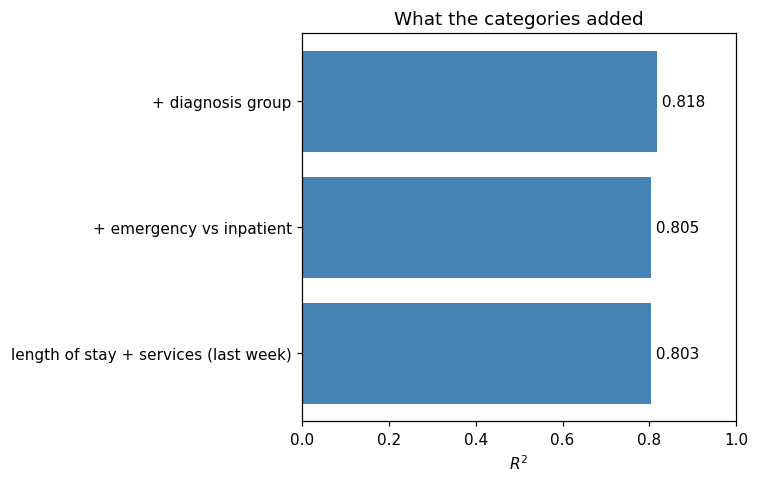

In [101]:
progress = pd.DataFrame({
    "model": ["length of stay + services (last week)",
              "+ emergency vs inpatient",
              "+ diagnosis group"],
    "R-squared": [model_log.rsquared, model_adjusted.rsquared, model_dx.rsquared],
})

plt.barh(progress.model, progress["R-squared"], color="steelblue")
plt.xlabel("$R^2$"); plt.xlim(0, 1)
plt.title("What the categories added")
for i, v in enumerate(progress["R-squared"]):
    plt.text(v, i, f" {v:.3f}", va="center")
plt.tight_layout(); plt.show()

Both categories are statistically significant, and together they add about 0.014 to $R^2$. That is a genuine improvement, but a modest one. **Length of stay and number of services remain the story**; the categories refine it rather than change it.

That is worth saying plainly, because the categorical variables are the ones that feel most informative to a clinician. Knowing a patient came through the emergency department, or was treated for a circulatory condition, feels like it should tell you a great deal about cost. It does — but almost all of that information is already contained in how long they stayed and how many services they received.

---
## 9. Summary

| Step | $R^2$ | What we learned |
|---|---|---|
| stay length + services | 0.803 | last week's model |
| + emergency vs inpatient | 0.805 | raw 8× effect falls to 1.2× once adjusted |
| + diagnosis group | 0.818 | injuries highest, respiratory lowest, vs reference |

**Five things to take away.**

1. **Categories enter a model as indicator variables** — a column of 0s and 1s for each group. Never code categories as 1, 2, 3.
2. **One group is always the reference**, and every coefficient is a comparison against it. A category with $k$ groups needs $k-1$ indicators.
3. **Always state the reference category.** Change it and every coefficient changes, while the model itself stays exactly the same.
4. **A raw group difference is not a group effect.** Inpatient events looked 8 times more expensive; comparing like with like, the setting itself accounts for about 21%. The rest was length of stay and complexity.
5. **Count your groups first.** A level with three events will still produce a confident-looking coefficient, and it will mean nothing.

### Still to come

- We have assumed each group has the same *slope* — that an extra day costs the same in an emergency visit as in an inpatient admission. It probably does not. Letting slopes differ between groups is called an **interaction**, and it is the next topic.
- All our $R^2$ values are measured on the same data used to fit the models, so they are optimistic.
- Our 3,361 events come from only 1,757 patients, so the rows are not fully independent.

**Next step:** interactions — when the effect of one variable depends on another.